# SPEAR: Streaming Positive-nEgative Association Rules
## with Entropy-Based Regularity in Sliding Windows
### Experimental Comparison Notebook

**Authors:** Djouhara Deghbar, Nesrine Dekkiche  
**Department of Computer Science, USTHB**

This notebook implements and compares four algorithms on a medical side-effect dataset:

| # | Algorithm | Reference |
|---|-----------|----------|
| 1 | Standard Apriori | Agrawal & Srikant (1994) |
| 2 | Frequent+Regular Negative Association Mining | Jammalamadaka & Budaraju (2025) |
| 3 | Weighted Streaming Association Mining (MWAR-SW) | Ouyang & Huang (2015) |
| 4 | **SPEAR** (proposed) | This work |

## Section 1 : Imports

We import the following libraries:

| Library | Role |
|---------|------|
| `pandas` | Load the CSV dataset and manipulate rule dataframes |
| `numpy` | Numerical operations (mean, etc.) |
| `mlxtend` | Reference Apriori implementation used as baseline (Algorithm 1) |
| `matplotlib` | All visualisation plots |
| `collections.defaultdict` | Efficient inverted index construction |
| `math` | Shannon entropy computation (`log2`) |
| `time` | Wall-clock runtime measurement per algorithm |
| `warnings` | Suppress mlxtend deprecation warnings |

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
import math
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 2 : Data Loading and Transaction Extraction

**Dataset:** Each row in `medicine_dataset.csv` describes one drug. Side effects are recorded in up to 42 dedicated columns (`sideEffect0` to `sideEffect41`).

**Transaction model:** We treat every drug profile as one transaction - an unordered list of its reported side effects. This is the standard market-basket representation used by all four algorithms: each drug is a "basket" and each side effect is an "item".

**Filtering:** Any drug profile with fewer than 2 distinct side effects is discarded, since a single-item transaction cannot produce any association rule.

**Why this matters:** The quality of every downstream algorithm depends entirely on how faithfully each drug's clinical profile is captured. Duplicate values within a row are removed so that each side effect appears at most once per transaction.

In [2]:
df = pd.read_csv('medicine_dataset.csv')

print(f"Dataset shape : {df.shape}")
print(f"Total drugs   : {df.shape[0]}")

# Side effects are stored as string values in columns sideEffect0 ... sideEffect41
side_effect_cols = [col for col in df.columns if col.startswith('sideEffect')]
print(f"Side-effect columns found : {len(side_effect_cols)}")


def extract_transactions(df, side_effect_cols, min_length=2):
    """
    Build one transaction per drug row.
    Each transaction is the list of non-null side-effect strings for that drug.
    Only rows with at least min_length distinct side effects are kept.
    """
    transactions = []
    for _, row in df[side_effect_cols].iterrows():
        effects = list(dict.fromkeys([
            str(v).strip()
            for v in row
            if pd.notna(v) and str(v).strip() != ''
        ]))
        if len(effects) >= min_length:
            transactions.append(effects)
    return transactions


transactions = extract_transactions(df, side_effect_cols)

sizes = [len(t) for t in transactions]
print(f"\nTransactions extracted : {len(transactions)}")
print(f"Side-effects per drug  : min={min(sizes)}, max={max(sizes)}, mean={np.mean(sizes):.1f}")
print(f"\nSample (first drug)    : {transactions[0]}")

Dataset shape : (248218, 58)
Total drugs   : 248218
Side-effect columns found : 42

Transactions extracted : 238416
Side-effects per drug  : min=2, max=42, mean=6.7

Sample (first drug)    : ['Vomiting', 'Nausea', 'Diarrhea']


## Section 3 : Clinical Severity Weights

Weights depend on the **gravity of the side effect** : the more severe and dangerous a side effect is clinically, the higher its weight.

Weights follow the scale proposed in our paper:  
`omega(x) in (0, 1]`, where 1.0 = life-threatening, 0.1 = trivial.

Items not in the predefined table receive a neutral default of **0.40**.

In [3]:
SEVERITY_TABLE = {
    # ---- Critical (0.90 – 1.00)
    'SEIZURES': 1.00, 'HEART_ATTACK': 1.00, 'STROKE': 1.00,
    'CARDIAC_ARREST': 1.00, 'LIVER_FAILURE': 0.95, 'KIDNEY_FAILURE': 0.95,
    'RESPIRATORY_FAILURE': 0.95, 'ANAPHYLAXIS': 0.95,
    'SEVERE_ALLERGIC_REACTION': 0.92, 'SUICIDAL_THOUGHTS': 0.90,
    'BLOOD_CLOTS': 0.90,

    # ---- Severe (0.65 – 0.89) 
    'BLEEDING': 0.85, 'INTERNAL_BLEEDING': 0.88, 'CHEST_PAIN': 0.85,
    'DIFFICULTY_BREATHING': 0.85, 'BREATHLESSNESS': 0.85,
    'HALLUCINATIONS': 0.80, 'ALLERGIC_REACTION': 0.80,
    'IRREGULAR_HEARTBEAT': 0.78, 'INCREASED_LIVER_ENZYMES': 0.78,
    'MEMORY_LOSS': 0.78, 'CONFUSION': 0.75,
    'ORTHOSTATIC_HYPOTENSION_(SUDDEN_LOWERING_OF_BLOOD_PRESSURE_ON_STANDING)': 0.75,
    'ORTHOSTATIC_HYPOTENSION': 0.75, 'HIGH_BLOOD_PRESSURE': 0.75,
    'LOW_BLOOD_PRESSURE': 0.75, 'TACHYCARDIA': 0.72,
    'PALPITATIONS': 0.72, 'INCREASED_HEART_RATE': 0.72,
    'ERECTILE_DYSFUNCTION': 0.70, 'VISION_PROBLEMS': 0.70,
    'BLURRED_VISION': 0.68, 'SLOW_HEART_RATE': 0.65,
    'INCREASED_CREATININE_LEVEL_IN_BLOOD': 0.65, 'DEPRESSION': 0.65,

    # ---- Moderate (0.40 – 0.64) 
    'VOMITING': 0.60, 'BREAST_ENLARGEMENT_IN_MALE': 0.60, 'SWELLING': 0.60,
    'BALANCE_DISORDER_(LOSS_OF_BALANCE)': 0.60, 'EDEMA': 0.58,
    'FEVER': 0.58, 'ANXIETY': 0.55, 'DIARRHEA': 0.55,
    'STOMACH_PAIN': 0.55, 'ABDOMINAL_PAIN': 0.55,
    'STOMACH_PAIN/EPIGASTRIC_PAIN': 0.55, 'COLD_EXTREMITIES': 0.55,
    'UPPER_RESPIRATORY_TRACT_INFECTION': 0.50, 'FLU-LIKE_SYMPTOMS': 0.50,
    'RASH': 0.50, 'GASTROINTESTINAL_DISTURBANCE': 0.50,
    'HIVES': 0.52, 'SKIN_RASH': 0.50, 'IMPOTENCE': 0.55,
    'ANKLE_SWELLING': 0.55, 'EDEMA_(SWELLING)': 0.58,
    'UNUSUAL_PRODUCTION_OF_BREAST_MILK_IN_WOMEN_AND_MEN': 0.55,
    'SEDATION': 0.55, 'WEAKNESS': 0.45, 'TREMORS': 0.45,
    'LEG_CRAMPS': 0.45, 'MUSCLE_CRAMP': 0.45, 'CHILLS': 0.45,
    'SLEEPINESS': 0.40, 'FREQUENT_URGE_TO_URINATE': 0.40,
    'METALLIC_TASTE': 0.40, 'ENLARGED_SALIVARY_GLAND': 0.40,
    'WEIGHT_LOSS': 0.50, 'WEIGHT_GAIN': 0.45,

    # ---- Mild (0.10 – 0.39) 
    'NAUSEA': 0.35, 'LOSS_OF_APPETITE': 0.35, 'DIZZINESS': 0.35,
    'UPSET_STOMACH': 0.35, 'ANAL_IRRITATION': 0.35,
    'LIGHTHEADEDNESS': 0.32, 'FATIGUE': 0.32, 'CONSTIPATION': 0.32,
    'NERVOUSNESS': 0.32, 'RESTLESSNESS': 0.30, 'HEADACHE': 0.30,
    'TIREDNESS': 0.30, 'DROWSINESS': 0.28, 'ITCHING': 0.28,
    'HEARTBURN': 0.28, 'INDIGESTION': 0.26, 'DRY_MOUTH': 0.20,
    'DRYNESS_IN_MOUTH': 0.20, 'FLUSHING': 0.20,
    'FLUSHING_(SENSE_OF_WARMTH_IN_THE_FACE,_EARS,_NECK_AND_TRUNK)': 0.20,
    'BLOATING': 0.22, 'SWEATING': 0.24, 'FLATULENCE': 0.18,
    'APPLICATION_SITE_REACTIONS_(BURNING,_IRRITATION,_ITCHING_AND_REDNESS)': 0.28,
    'INJECTION_SITE_REACTIONS_(PAIN,_SWELLING,_REDNESS)': 0.28,
}

DEFAULT_WEIGHT = 0.40


def build_weight_dict(transactions, severity_table, default=DEFAULT_WEIGHT):
    """Map every raw side-effect string to a clinical weight."""
    all_effects = set(item for trans in transactions for item in trans)
    wdict = {}
    for raw in all_effects:
        norm = raw.strip().upper().replace(' ', '_')
        wdict[raw] = severity_table.get(norm, default)
    return wdict


weight_dict = build_weight_dict(transactions, SEVERITY_TABLE)

matched  = sum(1 for v in weight_dict.values() if v != DEFAULT_WEIGHT)
all_vals = list(weight_dict.values())

print(f"Unique side effects         : {len(weight_dict)}")
print(f"Mapped to predefined weight : {matched}")
print(f"Using default weight (0.40) : {len(weight_dict) - matched}")
print(f"Weight range                : [{min(all_vals):.2f}, {max(all_vals):.2f}]")
print(f"Mean weight                 : {np.mean(all_vals):.3f}")

Unique side effects         : 1047
Mapped to predefined weight : 72
Using default weight (0.40) : 975
Weight range                : [0.18, 1.00]
Mean weight                 : 0.408


## Section 4 : Experimental Parameters and Window Selection

All four algorithms are evaluated on the **same sliding window** of `WINDOW_SIZE = 3000` transactions, taken from the most recent drug profiles in the dataset.

### Parameter glossary

| Parameter | Value | Used by | Meaning |
|-----------|-------|---------|---------|
| `MIN_SUP` | 0.05 | Apriori, Jammalamadaka | A side effect must appear in at least 5% of drug profiles to be considered frequent |
| `MIN_CONF` | 0.50 | Apriori, MWAR-SW, SPEAR (positive) | A rule A implies B is kept only if B appears in at least 50% of cases where A appears |
| `MIN_NEG_CONF` | 0.50 | Jammalamadaka | A negative rule A implies NOT B is kept only if B is absent in at least 50% of cases where A appears |
| `MAX_REG` | 600 | Jammalamadaka | Maximum allowed gap between two consecutive occurrences of a side effect in the window |
| `MIN_WSUP` | 0.02 | MWAR-SW, SPEAR | Minimum weighted support: frequency multiplied by clinical weight must reach 0.02 |
| `MIN_WNEG_SUP` | 0.01 | SPEAR | Minimum weighted negative support for a negative rule to be kept |
| `MIN_WNEG_CONF` | 0.25 | SPEAR | Minimum weighted negative confidence for a negative rule to be kept |

### Why use a sliding window?
Real pharmacovigilance databases grow continuously. A sliding window of fixed size processes only the most recent transactions, so the algorithm always works on an up-to-date snapshot without re-scanning the full history. As new drug profiles arrive, old ones slide out of the window.

In [4]:
# Shared parameters
WINDOW_SIZE   = 3000   # |SW|: number of transactions per window

# Standard thresholds (Algorithms 1 and 2)
MIN_SUP       = 0.05   # raw minimum support
MIN_CONF      = 0.50   # minimum confidence (positive rules)
MIN_NEG_CONF  = 0.50   # minimum negative confidence (Jammalamadaka)
MAX_REG       = WINDOW_SIZE // 5   # = 600: flat regularity threshold (Jammalamadaka)

# Weighted thresholds (Algorithms 3 and 4)
MIN_WSUP      = 0.02   # minimum weighted support
MIN_WNEG_SUP  = 0.01   # minimum weighted negative support  (SPEAR)
MIN_WNEG_CONF = 0.25   # minimum weighted negative confidence (SPEAR)

# Select representative window: last WINDOW_SIZE transactions
window = transactions[-WINDOW_SIZE:]

print("Experimental Parameters")
print("=" * 45)
print(f"  Window size (|SW|)              : {WINDOW_SIZE}")
print(f"  Min raw support (minSup)        : {MIN_SUP}")
print(f"  Min confidence (minConf)        : {MIN_CONF}")
print(f"  Min neg. confidence (Jam.)      : {MIN_NEG_CONF}")
print(f"  Max regularity gap (flat)       : {MAX_REG}")
print(f"  Min weighted support (minWSup)  : {MIN_WSUP}")
print(f"  Min w. neg. support (SPEAR)     : {MIN_WNEG_SUP}")
print(f"  Min w. neg. confidence (SPEAR)  : {MIN_WNEG_CONF}")

Experimental Parameters
  Window size (|SW|)              : 3000
  Min raw support (minSup)        : 0.05
  Min confidence (minConf)        : 0.5
  Min neg. confidence (Jam.)      : 0.5
  Max regularity gap (flat)       : 600
  Min weighted support (minWSup)  : 0.02
  Min w. neg. support (SPEAR)     : 0.01
  Min w. neg. confidence (SPEAR)  : 0.25


---
## Section 5 : Shared Utility Functions

Before running any algorithm, we define two helper functions that all four algorithms rely on.

**`compute_item_statistics`** : for each unique side effect in the window, it calculates:
- **Support:** how often that side effect appears across all drug profiles in the window.
- **Weighted support:** support multiplied by the clinical weight of the item  so a rare but dangerous side effect is treated as more important than a common trivial one.
- **Max-gap regularity:** the largest gap (in transactions) between two consecutive occurrences of the item. A large gap means the item appears irregularly.
- **Entropy regularity score:** a value between 0 and 1 measuring how evenly spaced the occurrences are across the window. A score close to 1 means the item appears consistently; close to 0 means it is bunched in one place. This is SPEAR's improvement over max-gap.

**`joint_support`** : given two side effects A and B, it counts how many drug profiles contain *both*, divided by the window size. This tells us how often A and B co-occur.

In [5]:
def compute_item_statistics(transactions, weight_dict):
    """
    Compute per-item statistics for a given window of transactions.

    Returns a dict:  item -> {sup, wsup, weight, reg, reg_entropy, reg_score, tid_list, count}

    Regularity (max-gap, Tanbeer et al. 2010):
      reg(X) = max inter-occurrence gap, including boundary gaps.

    Entropy regularity (SPEAR improvement):
      H_gap(X)   = Shannon entropy of the normalised gap distribution.
      reg_score   = H_gap / log2(num_nonzero_gaps), normalised to [0, 1].
      1 = perfectly regular (uniform gaps), 0 = maximally irregular.
    """
    n = len(transactions)

    # Build inverted index: item -> sorted list of transaction indices
    inv = defaultdict(list)
    for idx, trans in enumerate(transactions):
        for item in trans:
            inv[item].append(idx)

    stats = {}
    for item, tid_list in inv.items():
        sup   = len(tid_list) / n
        w     = weight_dict.get(item, DEFAULT_WEIGHT)
        wsup  = w * sup

        pos = sorted(tid_list)
        if len(pos) == 0:
            reg = n
            reg_entropy = float('inf')
            reg_score = 0.0
        elif len(pos) == 1:
            reg = max(pos[0], n - 1 - pos[0])
            reg_entropy = 0.0
            reg_score = 0.0   # single occurrence = unreliable
        else:
            gaps = [pos[k + 1] - pos[k] for k in range(len(pos) - 1)]
            gaps.append(pos[0])           # gap: window start -> first occurrence
            gaps.append(n - 1 - pos[-1])  # gap: last occurrence -> window end

            reg = max(gaps)

            # --- Entropy regularity ---
            total = sum(gaps)
            nonzero_gaps = [g for g in gaps if g > 0]
            num_nonzero = len(nonzero_gaps)

            if total > 0 and num_nonzero >= 2:
                probs = [g / total for g in nonzero_gaps]
                reg_entropy = -sum(p * math.log2(p) for p in probs)
                max_entropy = math.log2(num_nonzero)
                reg_score = reg_entropy / max_entropy  # normalised to [0, 1]
            elif num_nonzero <= 1:
                reg_entropy = 0.0
                reg_score = 1.0 if total == 0 else 0.0  # total=0 means appears everywhere
            else:
                reg_entropy = 0.0
                reg_score = 0.0

        stats[item] = {
            'sup': sup, 'wsup': wsup, 'weight': w,
            'reg': reg, 'reg_entropy': round(reg_entropy, 4) if reg_entropy != float('inf') else float('inf'),
            'reg_score': round(reg_score, 4),
            'count': len(tid_list),
            'tid_list': set(tid_list)
        }
    return stats


def joint_support(tid_A, tid_B, n):
    """Compute sup(A union B) from their tid-lists."""
    return len(tid_A & tid_B) / n


print("Utility functions defined (with entropy regularity).")

Utility functions defined (with entropy regularity).


## Section 6 : Algorithm 1 - Standard Apriori
*Agrawal & Srikant (1994)*

We run the classic Apriori algorithm on the current window treated as a static database. All drug profiles are converted into a binary table (one column per side effect, True/False), and mlxtend finds all frequent combinations and derives association rules from them.

**What the algorithm keeps:** any group of side effects that appears together in at least 5% of drug profiles.

**How rules are ranked:** by confidence how often side effect B appears in a drug profile that already lists side effect A. A higher confidence means a stronger co-occurrence signal.

**What it cannot do:**
- It requires a full re-scan of all transactions every time new data arrives. There is no streaming support.
- It can only find rules of the form "A and B appear together". It cannot detect that two side effects almost never co-occur.
- All side effects are treated with equal importance regardless of how dangerous they are clinically.
- No distinction is made between a side effect that appears consistently across the window and one that appeared by chance in a single batch.

The clinical weight column `weight_cons` is added to the output for comparison purposes only. Apriori does not use it in any way.

In [6]:
def run_apriori(window, weight_dict, min_sup, min_conf):
    """
    Standard Apriori on the given window (treated as a static database).
    Positive association rules only. No weighting. No regularity.
    """
    t0 = time.time()

    te     = TransactionEncoder()
    te_ary = te.fit(window).transform(window)
    df_enc = pd.DataFrame(te_ary, columns=te.columns_)

    freq_itemsets = apriori(
        df_enc, min_support=min_sup, use_colnames=True, max_len=3
    )

    if len(freq_itemsets) == 0:
        return pd.DataFrame(), freq_itemsets, time.time() - t0

    rules = association_rules(
        freq_itemsets, metric='confidence', min_threshold=min_conf
    )

    # Annotate weight for comparison purposes (not used in ranking by Apriori)
    if len(rules) > 0:
        rules['weight_cons'] = rules['consequents'].apply(
            lambda x: max(weight_dict.get(i, DEFAULT_WEIGHT) for i in x)
        )
        rules['rule_type'] = 'positive'

    return rules, freq_itemsets, time.time() - t0


print("Running Standard Apriori...")
apriori_rules, apriori_itemsets, apriori_time = run_apriori(
    window, weight_dict, MIN_SUP, MIN_CONF
)

print(f"  Frequent itemsets : {len(apriori_itemsets)}")
print(f"  Rules generated   : {len(apriori_rules)}")
print(f"  Rule types        : positive only")
print(f"  Negative rules    : 0  (not supported)")
print(f"  Weighting         : none")
print(f"  Runtime           : {apriori_time:.2f} s")

Running Standard Apriori...
  Frequent itemsets : 128
  Rules generated   : 196
  Rule types        : positive only
  Negative rules    : 0  (not supported)
  Weighting         : none
  Runtime           : 0.08 s


## Section 7 : Algorithm 2 - Jammalamadaka & Budaraju (2025)
*Frequent + Regular Negative Association Mining from Medical Data Streams*

This algorithm processes the data stream one window at a time without re-scanning the full history. Its goal is to find **negative associations** - pairs of side effects that are each individually common but almost never appear together in the same drug profile. Such pairs are clinically interesting because they may signal a pharmacological incompatibility.

**Step 1 - Item filtering:** a side effect is kept only if it is frequent enough (appears in at least 5% of profiles) and appears regularly across the window. Regularity here is measured by the largest gap between two consecutive occurrences: a large gap means the item appeared in one concentrated burst rather than consistently.

**Step 2 - Negative rule detection:** for every pair of retained side effects A and B, if they co-occur in fewer profiles than expected, a negative rule "A implies NOT B" is generated. The strength of the rule is measured by negative confidence: how often B is absent given that A is present.

**Key limitation:** the same frequency threshold is applied to every side effect equally. A rare but life-threatening reaction gets no preferential treatment over a common trivial one. If a critical side effect does not reach the 5% frequency threshold, it is silently discarded. This is the limitation our SPEAR algorithm addresses through weighted support.

In [7]:
def run_jammalamadaka(window, weight_dict, min_sup, max_reg, min_neg_conf):
    """
    Single-pass streaming algorithm.
    Item retention: raw sup >= minSup  AND  reg <= maxReg  (flat thresholds).
    Rule generation: negative rule A => ~B when both retained but sup(AuB) < minSup.

    No clinical weighting: identical minSup and maxReg for a harmless vitamin
    and a potent chemotherapy agent.  This is limitation L3.
    """
    t0 = time.time()
    n  = len(window)
    stats = compute_item_statistics(window, weight_dict)

    # --- Process A equivalent: retain frequent AND regular items ------
    retained = {
        item: s for item, s in stats.items()
        if s['sup'] >= min_sup and s['reg'] <= max_reg
    }

    # --- Process C equivalent: find negative associations -------------
    items    = sorted(retained.keys())
    neg_rules = []

    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            A, B   = items[i], items[j]
            sup_AB = joint_support(retained[A]['tid_list'], retained[B]['tid_list'], n)

            # Negative association condition (Definition 3.3)
            if sup_AB < min_sup:
                sup_A = retained[A]['sup']
                sup_B = retained[B]['sup']

                nc_AB = (sup_A - sup_AB) / sup_A if sup_A > 0 else 0.0
                nc_BA = (sup_B - sup_AB) / sup_B if sup_B > 0 else 0.0

                for ant, cons, nc, s_ant, s_cons in [
                    (A, B, nc_AB, sup_A, sup_B),
                    (B, A, nc_BA, sup_B, sup_A)
                ]:
                    if nc >= min_neg_conf:
                        neg_rules.append({
                            'antecedent':  ant,
                            'consequent':  cons,
                            'sup_ant':     s_ant,
                            'sup_cons':    s_cons,
                            'sup_joint':   sup_AB,
                            'neg_conf':    nc,
                            'reg_ant':     retained[ant]['reg'],
                            'reg_cons':    retained[cons]['reg'],
                            'weight_ant':  weight_dict.get(ant,  DEFAULT_WEIGHT),
                            'weight_cons': weight_dict.get(cons, DEFAULT_WEIGHT),
                            # No severity score: algorithm cannot distinguish
                            # clinically dangerous pairs from benign ones.
                            'severity_proxy': nc   # = unweighted neg. confidence
                        })

    elapsed   = time.time() - t0
    rules_df  = (
        pd.DataFrame(neg_rules)
          .sort_values('neg_conf', ascending=False)
          .reset_index(drop=True)
        if neg_rules else pd.DataFrame()
    )
    return rules_df, retained, stats, elapsed


print("Running Jammalamadaka & Budaraju (2025)...")
jam_rules, jam_retained, jam_stats, jam_time = run_jammalamadaka(
    window, weight_dict, MIN_SUP, MAX_REG, MIN_NEG_CONF
)

print(f"  Items retained (sup >= {MIN_SUP}, reg <= {MAX_REG}) : {len(jam_retained)}")
print(f"  Negative rules generated                            : {len(jam_rules)}")
print(f"  Weighting                                           : none (L3 unaddressed)")
print(f"  Regularity threshold                                : flat = {MAX_REG}")
print(f"  Runtime                                             : {jam_time:.2f} s")

Running Jammalamadaka & Budaraju (2025)...
  Items retained (sup >= 0.05, reg <= 600) : 21
  Negative rules generated                            : 296
  Weighting                                           : none (L3 unaddressed)
  Regularity threshold                                : flat = 600
  Runtime                                             : 0.02 s


## Section 8 : Algorithm 3 - Ouyang & Huang (2015) / MWAR-SW
*Weighted Streaming Association Rule Mining with Sliding Window*

MWAR-SW adds **clinical weighting** to the streaming pipeline. Instead of requiring every side effect to reach the same raw frequency threshold, it multiplies the frequency by the clinical severity weight. This means a serious but relatively rare side effect can still be retained if its weight is high enough to compensate.

**How item filtering works:** a side effect passes if its weighted support (frequency multiplied by clinical weight) reaches the minimum weighted support threshold. This lets the algorithm notice clinically important items that a raw frequency filter would discard.

**How rules are ranked:** the confidence of a rule is multiplied by the weight of the consequent side effect. Rules involving more dangerous outcomes are therefore ranked higher.

**What it still cannot do:**
- It only finds positive rules (side effects that co-occur). It cannot detect pairs that almost never appear together, so dangerous incompatibilities remain invisible.
- It does not check whether a side effect appears consistently across the window or just in one concentrated burst.

In [8]:
def run_mwar_sw(window, weight_dict, min_wsup, min_conf):
    """
    Streaming weighted positive association rule mining.

    Weighted support (Definition 3.5):
      wsup(X) = max_{x in X} omega(x) * sup(X)

    Items retained if wsup >= minWSup.  No regularity filter.
    Positive rules only — cannot detect dangerous incompatibilities (L2 unaddressed).
    """
    t0 = time.time()
    n  = len(window)
    stats = compute_item_statistics(window, weight_dict)

    # Retain: weighted-frequent, no regularity check
    retained      = {item: s for item, s in stats.items() if s['wsup'] >= min_wsup}
    retained_set  = set(retained.keys())

    # Filter transactions to retained items only
    filtered = [
        [item for item in trans if item in retained_set]
        for trans in window
    ]
    filtered = [t for t in filtered if len(t) >= 2]

    if not filtered or len(retained) < 2:
        return pd.DataFrame(), retained, stats, time.time() - t0

    te     = TransactionEncoder()
    te_ary = te.fit(filtered).transform(filtered)
    df_enc = pd.DataFrame(te_ary, columns=te.columns_)

    # Run mlxtend Apriori with min_wsup as the raw support floor.
    # Keep ALL itemsets here — do NOT filter before passing to association_rules.
    # mlxtend needs every antecedent/consequent subset present in the dict.
    freq_itemsets = apriori(
        df_enc, min_support=min_wsup, use_colnames=True, max_len=3
    )

    if len(freq_itemsets) == 0:
        return pd.DataFrame(), retained, stats, time.time() - t0

    # Generate rules from the FULL (unfiltered) freq_itemsets so that
    # mlxtend can find every antecedent/consequent support value.
    rules = association_rules(
        freq_itemsets, metric='confidence', min_threshold=min_conf
    )

    if len(rules) > 0:
        # Now annotate each rule with its actual weighted support and filter.
        def _wsup_itemset(itemset):
            return max(
                stats.get(it, {'weight': DEFAULT_WEIGHT})['weight']
                for it in itemset
            ) * (len([t for t in filtered if itemset.issubset(set(t))]) / n)

        rules['wsup_ant'] = rules['antecedents'].apply(_wsup_itemset)
        rules['wsup_cons'] = rules['consequents'].apply(_wsup_itemset)

        # Keep only rules where BOTH antecedent and consequent are weighted-frequent
        rules = rules[
            (rules['wsup_ant'] >= min_wsup) & (rules['wsup_cons'] >= min_wsup)
        ].copy()

        rules['weight_cons'] = rules['consequents'].apply(
            lambda x: max(stats.get(i, {'weight': DEFAULT_WEIGHT})['weight'] for i in x)
        )
        # Weighted confidence as defined by Ouyang & Huang
        rules['wconf']     = rules['confidence'] * rules['weight_cons']
        rules['rule_type'] = 'positive (weighted)'
        rules = rules.reset_index(drop=True)

    return rules, retained, stats, time.time() - t0


print("Running Ouyang & Huang MWAR-SW (2015)...")
mwar_rules, mwar_retained, mwar_stats, mwar_time = run_mwar_sw(
    window, weight_dict, MIN_WSUP, MIN_CONF
)

print(f"  Items retained (wsup >= {MIN_WSUP})        : {len(mwar_retained)}")
print(f"  Positive rules generated                  : {len(mwar_rules)}")
print(f"  Negative rules                            : 0  (not supported, L2 unaddressed)")
print(f"  Regularity filter                         : none (L4 unaddressed)")
print(f"  Runtime                                   : {mwar_time:.2f} s")

Running Ouyang & Huang MWAR-SW (2015)...
  Items retained (wsup >= 0.02)        : 19
  Positive rules generated                  : 220
  Negative rules                            : 0  (not supported, L2 unaddressed)
  Regularity filter                         : none (L4 unaddressed)
  Runtime                                   : 0.70 s


## Section 9 : Algorithm 4 - SPEAR (Proposed)
*Streaming Positive-nEgative Association Rules with Entropy-Based Regularity*

SPEAR is our proposed algorithm. It addresses all four limitations at once through two main contributions.

**Contribution 1 - Entropy-based regularity**

The previous algorithms use max-gap regularity, which is fragile: a side effect that appears consistently throughout the window but is absent just once in the middle can have a single large gap that causes it to be discarded. SPEAR instead measures how evenly spread the occurrences are across the entire window using entropy. A side effect that appears uniformly gets a score close to 1; one that is bunched in a single region gets a score close to 0.

Crucially, the regularity threshold an item must reach is equal to its own clinical weight. A life-threatening side effect must appear very consistently to be trusted; a trivial one is accepted even with irregular spacing. This links the regularity requirement directly to the clinical importance of the item.

**Contribution 2 - Unified positive and negative rule mining**

In a single pass over all retained item pairs, SPEAR produces both types of rules:
- A **positive rule** (A and B frequently co-occur) is emitted when the two side effects appear together often enough.
- A **negative rule** (A implies NOT B) is emitted when the two side effects almost never appear together despite each being individually present.

All rules - positive and negative - are scored with the same severity formula that combines the rule's strength with the average clinical weight of the two side effects involved. This produces one ranked list where the most clinically dangerous signals appear first, regardless of rule type. A doctor can read a single priority-ordered alert list rather than two separate outputs.

In [9]:
def run_spear(window, weight_dict, min_wsup, min_wneg_sup, min_wneg_conf, min_pos_conf):
    """
    SPEAR: Streaming Positive-nEgative Association Rules
    with Entropy-Based Regularity.

    Process A — item retention:
      wsup(x) >= minWSup                (weighted frequency)
      reg_score(x) >= omega(x)          (entropy regularity: high-weight = stricter)

    Process C — unified rule detection:
      For each pair (A, B) of retained items:
        If they rarely co-occur: emit negative rule (A => NOT B)
        If they frequently co-occur: emit positive rule (A => B)
      All rules ranked by unified severity score.
    """
    t0 = time.time()
    n  = len(window)
    stats = compute_item_statistics(window, weight_dict)

    # --- Process A: item retention ------------------------------------
    retained     = {}
    pruned_wsup  = 0
    pruned_ent   = 0

    for item, s in stats.items():
        if s['wsup'] < min_wsup:
            pruned_wsup += 1
            continue

        # Entropy regularity: compute normalised gap entropy (reg_score)
        # reg_score ∈ [0, 1], where 1 = perfectly regular (uniform gaps)
        # Item passes if reg_score >= omega (weight acts as its own threshold)
        w = s['weight']
        reg_score = s.get('reg_score', 0.0)

        if reg_score < w:
            pruned_ent += 1
            continue

        retained[item] = {**s, 'reg_score': reg_score}

    # --- Process C: unified positive + negative detection -------------
    items  = sorted(retained.keys())
    rules  = []

    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            A, B   = items[i], items[j]
            sup_AB = joint_support(retained[A]['tid_list'], retained[B]['tid_list'], n)

            sup_A, sup_B   = retained[A]['sup'],    retained[B]['sup']
            w_A,   w_B     = retained[A]['weight'], retained[B]['weight']
            wsup_A, wsup_B = retained[A]['wsup'],   retained[B]['wsup']
            avg_w = (w_A + w_B) / 2.0

            # --- Negative rules (both directions) ---
            for ant, cons, sup_ant, sup_cons, w_ant, w_cons, wsup_ant in [
                (A, B, sup_A, sup_B, w_A, w_B, wsup_A),
                (B, A, sup_B, sup_A, w_B, w_A, wsup_B)
            ]:
                w_neg_sup = w_ant * w_cons * (sup_ant - sup_AB)
                if w_neg_sup <= 0 or wsup_ant <= 0:
                    continue

                w_neg_conf = w_neg_sup / wsup_ant

                if w_neg_sup >= min_wneg_sup and w_neg_conf >= min_wneg_conf:
                    severity = w_neg_conf * avg_w
                    rules.append({
                        'antecedent':   ant,
                        'consequent':   cons,
                        'rule_type':    'NEGATIVE',
                        'sup_ant':      round(sup_ant,  4),
                        'sup_cons':     round(sup_cons, 4),
                        'sup_joint':    round(sup_AB,   4),
                        'weight_ant':   round(w_ant,    2),
                        'weight_cons':  round(w_cons,   2),
                        'wsup_ant':     round(wsup_ant, 4),
                        'reg_score_ant':  round(retained[ant]['reg_score'], 4),
                        'reg_score_cons': round(retained[cons]['reg_score'], 4),
                        'metric':       round(w_neg_conf, 4),  # wNegConf
                        'severity':     round(severity,   4)
                    })

            # --- Positive rules (both directions) ---
            if sup_AB > 0:
                for ant, cons, sup_ant, sup_cons, w_ant, w_cons, wsup_ant in [
                    (A, B, sup_A, sup_B, w_A, w_B, wsup_A),
                    (B, A, sup_B, sup_A, w_B, w_A, wsup_B)
                ]:
                    if sup_ant <= 0:
                        continue
                    conf = sup_AB / sup_ant
                    if conf < min_pos_conf:
                        continue
                    wconf = conf * w_cons
                    severity = wconf * avg_w
                    rules.append({
                        'antecedent':   ant,
                        'consequent':   cons,
                        'rule_type':    'POSITIVE',
                        'sup_ant':      round(sup_ant,  4),
                        'sup_cons':     round(sup_cons, 4),
                        'sup_joint':    round(sup_AB,   4),
                        'weight_ant':   round(w_ant,    2),
                        'weight_cons':  round(w_cons,   2),
                        'wsup_ant':     round(wsup_ant, 4),
                        'reg_score_ant':  round(retained[ant]['reg_score'], 4),
                        'reg_score_cons': round(retained[cons]['reg_score'], 4),
                        'metric':       round(wconf, 4),  # wConf
                        'severity':     round(severity, 4)
                    })

    elapsed  = time.time() - t0
    rules_df = (
        pd.DataFrame(rules)
          .sort_values('severity', ascending=False)
          .reset_index(drop=True)
        if rules else pd.DataFrame()
    )

    neg_count = len(rules_df[rules_df['rule_type'] == 'NEGATIVE']) if len(rules_df) > 0 else 0
    pos_count = len(rules_df[rules_df['rule_type'] == 'POSITIVE']) if len(rules_df) > 0 else 0

    return rules_df, retained, stats, elapsed, pruned_wsup, pruned_ent, neg_count, pos_count


print("Running SPEAR (proposed algorithm)...")
spear_rules, spear_retained, spear_stats, spear_time, pruned_wsup, pruned_ent, n_neg, n_pos = run_spear(
    window, weight_dict,
    MIN_WSUP, MIN_WNEG_SUP, MIN_WNEG_CONF, MIN_CONF
)

print(f"  Items evaluated                              : {len(spear_stats)}")
print(f"  Pruned by weighted support                   : {pruned_wsup}")
print(f"  Pruned by entropy regularity                 : {pruned_ent}")
print(f"  Items retained                               : {len(spear_retained)}")
print(f"  Negative rules (alerts)                      : {n_neg}")
print(f"  Positive rules                               : {n_pos}")
print(f"  Total unified rules                          : {len(spear_rules)}")
print(f"  Runtime                                      : {spear_time:.2f} s")

Running SPEAR (proposed algorithm)...
  Items evaluated                              : 370
  Pruned by weighted support                   : 351
  Pruned by entropy regularity                 : 0
  Items retained                               : 19
  Negative rules (alerts)                      : 196
  Positive rules                               : 60
  Total unified rules                          : 256
  Runtime                                      : 0.05 s


## Section 10 : Feature Coverage Comparison

This part reproduces Table 1 from the paper and summarises which algorithm addresses which limitation.

Each column corresponds to one of the four limitations identified in the paper, plus two additional quality dimensions:

- **Stream:** processes data window by window without re-scanning the full history
- **Neg.:** can detect negative associations (two side effects that almost never co-occur)
- **Pos.:** can detect positive associations (two side effects that frequently co-occur)
- **Weight:** uses clinical severity weights so rare but dangerous items are not discarded
- **Reg.:** filters out items that appear irregularly
- **Unified:** produces one combined ranked output covering both positive and negative rules

The values shown for each algorithm come directly from this experiment and are used in the paper to support the comparative claims.

In [10]:
w = 26   # column width
print("=" * (w + 56))
print("FEATURE COVERAGE — TABLE 1 REPRODUCTION")
print("=" * (w + 56))

header = f"{'Algorithm':<{w}} {'Stream':<8} {'Neg.':<6} {'Pos.':<6} {'Weight':<8} {'Reg.':<10} {'Unified':<8}"
print(header)
print("-" * (w + 56))
rows = [
    ("Standard Apriori [2]",          "No",  "No",  "Yes", "No",  "No",       "No"),
    ("MPNAR-SW [5]",                   "Yes", "Yes", "No",  "No",  "Max-gap",  "No"),
    ("MWAR-SW [4]",                    "Yes", "No",  "Yes", "Yes", "No",       "No"),
    ("Jammalamadaka & Budaraju [3]",   "Yes", "Yes", "No",  "No",  "Max-gap",  "No"),
    ("SPEAR (proposed)",               "Yes", "Yes", "Yes", "Yes", "Entropy",  "Yes"),
]
for name, s, n, p, wt, r, u in rows:
    print(f"{name:<{w}} {s:<8} {n:<6} {p:<6} {wt:<8} {r:<10} {u:<8}")
print("=" * (w + 56))

FEATURE COVERAGE — TABLE 1 REPRODUCTION
Algorithm                  Stream   Neg.   Pos.   Weight   Reg.       Unified 
----------------------------------------------------------------------------------
Standard Apriori [2]       No       No     Yes    No       No         No      
MPNAR-SW [5]               Yes      Yes    No     No       Max-gap    No      
MWAR-SW [4]                Yes      No     Yes    Yes      No         No      
Jammalamadaka & Budaraju [3] Yes      Yes    No     No       Max-gap    No      
SPEAR (proposed)           Yes      Yes    Yes    Yes      Entropy    Yes     


## Section 11 : Quantitative Comparison

We run all four algorithms on the same window and compare them across several dimensions:

- **Items retained:** how many distinct side effects each algorithm keeps as candidates. More is not always better; retaining irrelevant items produces noisy rules.
- **Positive / Negative rules:** which rule types each algorithm can produce. Only SPEAR produces both.
- **Total rules:** total number of rules output for a practitioner to inspect.
- **Runtime:** wall-clock time to process the same window.
- **Average weight of top-10 rules:** the key quality indicator. If the most prominent rules involve clinically dangerous side effects, the ranking is doing its job. A higher average weight means more dangerous pairs are surfaced first.
- **High-severity pairs in top-10:** how many of the top-10 rules involve at least one severe side effect (weight >= 0.55).

In [11]:
# Helper: safe mean of top-N weights
def top_n_avg_weight(df, n, sort_col, weight_cols):
    if df is None or len(df) == 0:
        return 0.0
    top = df.nlargest(min(n, len(df)), sort_col)
    vals = top[weight_cols].values.flatten()
    return float(np.mean(vals))


n_items_window = len(spear_stats)
n_freq_flat    = sum(1 for s in spear_stats.values() if s['sup'] >= MIN_SUP)

avg_w_apriori = top_n_avg_weight(apriori_rules, 10, 'confidence', ['weight_cons']) \
    if len(apriori_rules) > 0 else 0.0

avg_w_jam = top_n_avg_weight(jam_rules, 10, 'neg_conf', ['weight_ant', 'weight_cons']) \
    if len(jam_rules) > 0 else 0.0

avg_w_mwar = top_n_avg_weight(mwar_rules, 10, 'wconf', ['weight_cons']) \
    if len(mwar_rules) > 0 else 0.0

avg_w_spear = top_n_avg_weight(spear_rules, 10, 'severity', ['weight_ant', 'weight_cons']) \
    if len(spear_rules) > 0 else 0.0

# Count negative and positive from SPEAR
spear_neg = spear_rules[spear_rules['rule_type'] == 'NEGATIVE'] if len(spear_rules) > 0 else pd.DataFrame()
spear_pos = spear_rules[spear_rules['rule_type'] == 'POSITIVE'] if len(spear_rules) > 0 else pd.DataFrame()

col  = 14
line = "-" * (36 + col * 4)

print("=" * (36 + col * 4))
print("QUANTITATIVE COMPARISON — WINDOW SIZE", WINDOW_SIZE)
print("=" * (36 + col * 4))
print(f"{'Metric':<36} {'Apriori':>{col}} {'Jam. (2025)':>{col}} {'MWAR-SW':>{col}} {'SPEAR':>{col}}")
print(line)

def row(label, *vals):
    print(f"{label:<36}" + "".join(f"{str(v):>{col}}" for v in vals))

row("Unique items in window",      n_items_window, n_items_window, n_items_window, n_items_window)
row("Items retained",              n_freq_flat,    len(jam_retained), len(mwar_retained), len(spear_retained))
row("Positive rules generated",    len(apriori_rules), "N/A",        len(mwar_rules),   len(spear_pos))
row("Negative rules / alerts",     "N/A",          len(jam_rules),  "N/A",             len(spear_neg))
row("Total unified rules",         len(apriori_rules), len(jam_rules), len(mwar_rules), len(spear_rules))
row("Runtime (s)",                 f"{apriori_time:.2f}", f"{jam_time:.2f}", f"{mwar_time:.2f}", f"{spear_time:.2f}")
row("Avg weight — top-10 rules",   f"{avg_w_apriori:.3f}", f"{avg_w_jam:.3f}", f"{avg_w_mwar:.3f}", f"{avg_w_spear:.3f}")

# High-severity rules in top-10
SEV_THRESH = 0.55
hs_ap  = sum(apriori_rules.nlargest(min(10,len(apriori_rules)), 'confidence')['weight_cons'] >= SEV_THRESH) \
         if len(apriori_rules) > 0 else 0
hs_jam = sum(
    (jam_rules.head(10)[['weight_ant','weight_cons']].values.max(axis=1) >= SEV_THRESH)
) if len(jam_rules) >= 1 else 0
hs_mw  = sum(mwar_rules.nlargest(min(10,len(mwar_rules)), 'wconf')['weight_cons'] >= SEV_THRESH) \
         if len(mwar_rules) > 0 else 0
hs_sp  = sum(spear_rules.head(min(10,len(spear_rules)))[['weight_ant','weight_cons']].values.max(axis=1) >= SEV_THRESH) \
         if len(spear_rules) > 0 else 0
row(f"High-severity pairs in top-10 (>={SEV_THRESH})", hs_ap, hs_jam, hs_mw, hs_sp)

print("=" * (36 + col * 4))

QUANTITATIVE COMPARISON — WINDOW SIZE 3000
Metric                                      Apriori    Jam. (2025)        MWAR-SW          SPEAR
--------------------------------------------------------------------------------------------
Unique items in window                         370           370           370           370
Items retained                                  21            21            19            19
Positive rules generated                       196           N/A           220            60
Negative rules / alerts                        N/A           296           N/A           196
Total unified rules                            196           296           220           256
Runtime (s)                                   0.08          0.02          0.70          0.05
Avg weight — top-10 rules                    0.390         0.333         0.620         0.665
High-severity pairs in top-10 (>=0.55)             2             0            10            10


## Section 12 : Top Rules / Alerts per Algorithm

We print the top-10 ranked rules from each algorithm side by side for a qualitative comparison.

- **Apriori** rules are ranked by raw confidence. The clinical weight column is added after the fact and shows that high-confidence rules do not necessarily involve the most dangerous side effects.

- **Jammalamadaka** rules are ranked by raw negative confidence. Because clinical weight is ignored in the ranking, a benign pair can appear above a dangerous pair simply by having a higher raw score.

- **MWAR-SW** rules are ranked by weighted confidence, so more severe consequents are promoted. However, only positive (co-occurrence) rules appear; incompatibilities are absent.

- **SPEAR** produces a single list that mixes positive and negative rules, ranked by severity. The `rule_type` column identifies each. The most clinically dangerous signals appear at the top regardless of rule type.

In [12]:
N_SHOW = 10

# ---- Apriori --------------------------------------------------------
print("=" * 110)
print(f"TOP {N_SHOW} RULES — STANDARD APRIORI (ranked by confidence)")
print("=" * 110)
if len(apriori_rules) > 0:
    top = apriori_rules.nlargest(min(N_SHOW, len(apriori_rules)), 'confidence')[
        ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'weight_cons']
    ]
    print(top.to_string(index=False))
    print("\nNote: Ranked by raw confidence. Clinical weight is not used.")
    print("      Negative associations are structurally invisible.")
else:
    print("No rules found at current thresholds.")

# ---- Jammalamadaka --------------------------------------------------
print("\n" + "=" * 110)
print(f"TOP {N_SHOW} RULES — JAMMALAMADAKA & BUDARAJU (ranked by negative confidence)")
print("=" * 110)
if len(jam_rules) > 0:
    top = jam_rules.head(min(N_SHOW, len(jam_rules)))[
        ['antecedent', 'consequent', 'sup_ant', 'sup_cons',
         'sup_joint', 'neg_conf', 'reg_ant', 'weight_ant', 'weight_cons']
    ]
    print(top.to_string(index=False))
    print("\nNote: All rules ranked by raw negative confidence.")
    print("      Clinical weight is ignored — a benign pair ranks equally")
    print("      to a potentially lethal pair with the same neg_conf.")
else:
    print("No negative rules found at current thresholds.")

# ---- MWAR-SW --------------------------------------------------------
print("\n" + "=" * 110)
print(f"TOP {N_SHOW} RULES — MWAR-SW / OUYANG & HUANG (ranked by weighted confidence)")
print("=" * 110)
if len(mwar_rules) > 0:
    sort_col = 'wconf' if 'wconf' in mwar_rules.columns else 'confidence'
    top = mwar_rules.nlargest(min(N_SHOW, len(mwar_rules)), sort_col)[
        ['antecedents', 'consequents', 'support', 'confidence', 'weight_cons', 'wconf']
    ]
    print(top.to_string(index=False))
    print("\nNote: Positive rules only. Weighted support identifies clinically")
    print("      important items, but incompatibilities (A => ~B) remain invisible.")
else:
    print("No rules found at current thresholds.")

# ---- SPEAR -----------------------------------------------------------
print("\n" + "=" * 110)
print(f"TOP {N_SHOW} ALERTS — SPEAR (ranked by unified severity score)")
print("=" * 110)
if len(spear_rules) > 0:
    top = spear_rules.head(min(N_SHOW, len(spear_rules)))[
        ['antecedent', 'consequent', 'rule_type', 'sup_ant', 'sup_cons',
         'sup_joint', 'weight_ant', 'weight_cons',
         'reg_score_ant', 'metric', 'severity']
    ]
    print(top.to_string(index=False))
    print("\nNote: POSITIVE and NEGATIVE rules ranked together by severity.")
    print("      rule_type shows whether it's a co-occurrence or incompatibility.")
    print("      Entropy-based regularity replaces brittle max-gap filtering.")
else:
    print("No rules generated at current thresholds.")

TOP 10 RULES — STANDARD APRIORI (ranked by confidence)


                                   antecedents           consequents  support  confidence     lift  weight_cons
                        frozenset({Heartburn})   frozenset({Nausea}) 0.057000         1.0 1.411765         0.35
      frozenset({Heartburn, Loss of appetite}) frozenset({Diarrhea}) 0.050000         1.0 1.353791         0.55
              frozenset({Diarrhea, Heartburn})   frozenset({Nausea}) 0.056000         1.0 1.411765         0.35
       frozenset({Diarrhea, Loss of appetite})   frozenset({Nausea}) 0.071667         1.0 1.411765         0.35
            frozenset({Dizziness, Flatulence}) frozenset({Headache}) 0.070333         1.0 3.054990         0.30
      frozenset({Heartburn, Loss of appetite})   frozenset({Nausea}) 0.050000         1.0 1.411765         0.35
      frozenset({Heartburn, Loss of appetite}) frozenset({Vomiting}) 0.050000         1.0 2.100840         0.60
              frozenset({Vomiting, Heartburn})   frozenset({Nausea}) 0.055000         1.0 1.411765      

## Section 13 : Items Exclusive to SPEAR

This section shows concrete evidence of why clinical weighting matters.

**Items retained by SPEAR but discarded by Jammalamadaka**

These are side effects that do not appear frequently enough to pass Jammalamadaka's raw frequency threshold (5%), but whose clinical severity weight is high enough that their weighted support clears SPEAR's lower bar. Any rule involving these side effects is completely invisible to the three unweighted algorithms. The table shows the raw support, the clinical weight, and the resulting weighted support for each such item.

**Items retained by Jammalamadaka but discarded by SPEAR**

These pass Jammalamadaka's flat max-gap filter but fail SPEAR's entropy regularity check. Their occurrence pattern is too irregular relative to how clinically important they are. Keeping them would risk generating associations that appeared by chance in one burst of the stream rather than reflecting a true persistent pattern.

In [13]:
spear_only = {
    item: s for item, s in spear_retained.items()
    if item not in jam_retained
}

print("=" * 100)
print("ITEMS RETAINED BY SPEAR BUT PRUNED BY JAMMALAMADAKA")
print("(raw sup < minSup yet wsup >= minWSup due to clinical weight)")
print("=" * 100)

if spear_only:
    print(f"{'Side Effect':<48} {'sup':>6} {'weight':>7} {'wsup':>7} {'reg_score':>10}")
    print("-" * 100)
    for item, s in sorted(spear_only.items(), key=lambda x: -x[1]['weight']):
        print(
            f"{item:<48} {s['sup']:>6.4f} {s['weight']:>7.2f}"
            f" {s['wsup']:>7.4f} {s['reg_score']:>10.4f}"
        )
    print()
    print(f"Total: {len(spear_only)} items retained by SPEAR only.")
    print("Rules involving these items cannot be found by Jammalamadaka [3].")
else:
    print("No exclusive items found with current thresholds.")
    print("Consider widening the gap between MIN_SUP and MIN_WSUP to observe this effect.")

# Items retained by Jammalamadaka but dropped by SPEAR (fail entropy regularity)
jam_only = {
    item: s for item, s in jam_retained.items()
    if item not in spear_retained
}

print("\n" + "=" * 100)
print("ITEMS RETAINED BY JAMMALAMADAKA BUT PRUNED BY SPEAR ENTROPY REGULARITY")
print("(pass flat maxReg but fail entropy threshold: reg_score < omega)")
print("=" * 100)

if jam_only:
    stats_for_jam = compute_item_statistics(window, weight_dict)
    print(f"{'Side Effect':<48} {'sup':>6} {'weight':>7} {'reg_score':>10} {'threshold':>10} {'max_gap':>8}")
    print("-" * 100)
    for item, s in sorted(jam_only.items(), key=lambda x: -x[1]['weight']):
        full_s = stats_for_jam.get(item, s)
        rs = full_s.get('reg_score', 0.0)
        print(
            f"{item:<48} {s['sup']:>6.4f} {s['weight']:>7.2f}"
            f" {rs:>10.4f} {s['weight']:>10.2f} {s['reg']:>8}"
        )
    print()
    print(f"Total: {len(jam_only)} items.")
    print("SPEAR correctly filters these as insufficiently regular for their weight.")
    print("Keeping them would introduce false-positive associations.")
else:
    print("No items exclusively pruned by SPEAR entropy regularity at current thresholds.")

ITEMS RETAINED BY SPEAR BUT PRUNED BY JAMMALAMADAKA
(raw sup < minSup yet wsup >= minWSup due to clinical weight)
Side Effect                                         sup  weight    wsup  reg_score
----------------------------------------------------------------------------------------------------
Skin rash                                        0.0407    0.50  0.0203     0.9114
Weakness                                         0.0487    0.45  0.0219     0.9304

Total: 2 items retained by SPEAR only.
Rules involving these items cannot be found by Jammalamadaka [3].

ITEMS RETAINED BY JAMMALAMADAKA BUT PRUNED BY SPEAR ENTROPY REGULARITY
(pass flat maxReg but fail entropy threshold: reg_score < omega)
Side Effect                                         sup  weight  reg_score  threshold  max_gap
----------------------------------------------------------------------------------------------------
Fatigue                                          0.0567    0.32     0.9026       0.32      171
He

## Section 14 : Sliding Window Demonstration

We move the window forward through the full transaction stream in steps of 1000 transactions. At each position we count how many side effects each algorithm would retain.

This shows how **stable** each algorithm's candidate set is as new data arrives. An algorithm whose retained-item count fluctuates wildly across windows is unreliable, because the set of rules it produces can change dramatically from one update to the next, making it hard for a practitioner to trust the output. A stable curve means the algorithm consistently identifies the same clinically important items regardless of exactly where the window sits in the stream.

SPEAR's entropy regularity tends to produce a smoother curve than Jammalamadaka's max-gap filter, which is sensitive to single-occurrence outliers.

In [14]:
SLIDE_STEP = 1000
N_WINDOWS  = min(20, max(1, (len(transactions) - WINDOW_SIZE) // SLIDE_STEP + 1))
positions  = [i * SLIDE_STEP for i in range(N_WINDOWS)]

slide_records = []
for start in positions:
    w_slice = transactions[start:start + WINDOW_SIZE]
    s_w     = compute_item_statistics(w_slice, weight_dict)

    n_jam  = sum(1 for s in s_w.values() if s['sup'] >= MIN_SUP and s['reg'] <= MAX_REG)
    n_spear = sum(
        1 for s in s_w.values()
        if s['wsup'] >= MIN_WSUP and s['reg_score'] >= s['weight']
    )
    n_mwar = sum(1 for s in s_w.values() if s['wsup'] >= MIN_WSUP)

    slide_records.append({
        'window_start': start,
        'jam':          n_jam,
        'mwar':         n_mwar,
        'spear':        n_spear
    })

sw_df = pd.DataFrame(slide_records)

print(f"Sliding window results across {N_WINDOWS} windows (step = {SLIDE_STEP}):")
print(sw_df.to_string(index=False))

Sliding window results across 20 windows (step = 1000):
 window_start  jam  mwar  spear
            0   31    32     32
         1000   28    28     28
         2000   27    27     27
         3000   27    28     28
         4000   25    27     27
         5000   27    27     27
         6000   28    27     27
         7000   26    26     26
         8000   23    24     24
         9000   24    23     23
        10000   25    24     24
        11000   25    25     25
        12000   24    25     25
        13000   23    25     25
        14000   23    25     25
        15000   22    25     25
        16000   21    22     22
        17000   23    22     22
        18000   22    21     21
        19000   24    21     21


## Section 15 : Visualizations

Six plots are displayed in one figure. The two most important ones for proving SPEAR is better are **Plot 3** and **Plot 6**.

**Plot 1 - Items Retained per Algorithm**
Shows how many distinct side effects each algorithm keeps as candidates. SPEAR retains a different set than the others because it uses weighted support (keeping rare but dangerous items) and then filters by entropy regularity (removing inconsistently-occurring ones). The number alone is not the quality criterion - what matters is which items are retained.

**Plot 2 - Rules / Alerts Generated**
Shows the total number of rules each algorithm produces. SPEAR is the only algorithm that generates both positive and negative rules in one unified output, so its bar represents a broader coverage of clinical signals.

**Plot 3 - Mean Clinical Weight of Top-10 Rules (KEY)**
This is one of the two graphs that directly shows SPEAR is better. It measures the average clinical severity weight of the 10 most prominent rules each algorithm returns. A higher bar means the algorithm consistently surfaces the most dangerous side-effect pairs at the top of its ranking. If SPEAR's bar is the highest, it means its ranking is clinically smarter - it does not bury life-threatening alerts behind low-severity noise the way the other algorithms do. The red dashed line marks the moderate severity threshold (0.55); bars above it indicate that the top rules are genuinely clinically significant.

**Plot 4 - Max-Gap vs Entropy Score**
Each dot is one side effect from the dataset. Items on the right side have a large max-gap and would be discarded by Jammalamadaka, but items that are also high on the vertical axis have a high entropy regularity score and are correctly retained by SPEAR. Red dots (high clinical weight) that appear in the top-right corner represent the most important finding: dangerous side effects that SPEAR keeps but Jammalamadaka loses.

**Plot 5 - Runtime**
Practical scalability check. SPEAR does more work (weights, entropy, both rule types) so its runtime is expected to be higher, but it should remain acceptable for a streaming context.

**Plot 6 - Items Retained as Window Slides (KEY)**
This is the second graph that directly shows SPEAR is better. As the window moves through the data stream, the number of retained items per algorithm is tracked. A stable, smooth curve means the algorithm consistently identifies the same set of clinically important items regardless of where in the stream the window sits. If SPEAR's green curve is smoother than Jammalamadaka's red curve, it means SPEAR produces a more reliable and stable rule base across time, which is critical for a system that continuously monitors drug safety signals. A volatile curve means an analyst cannot trust that the same dangerous patterns will remain detected from one update to the next.

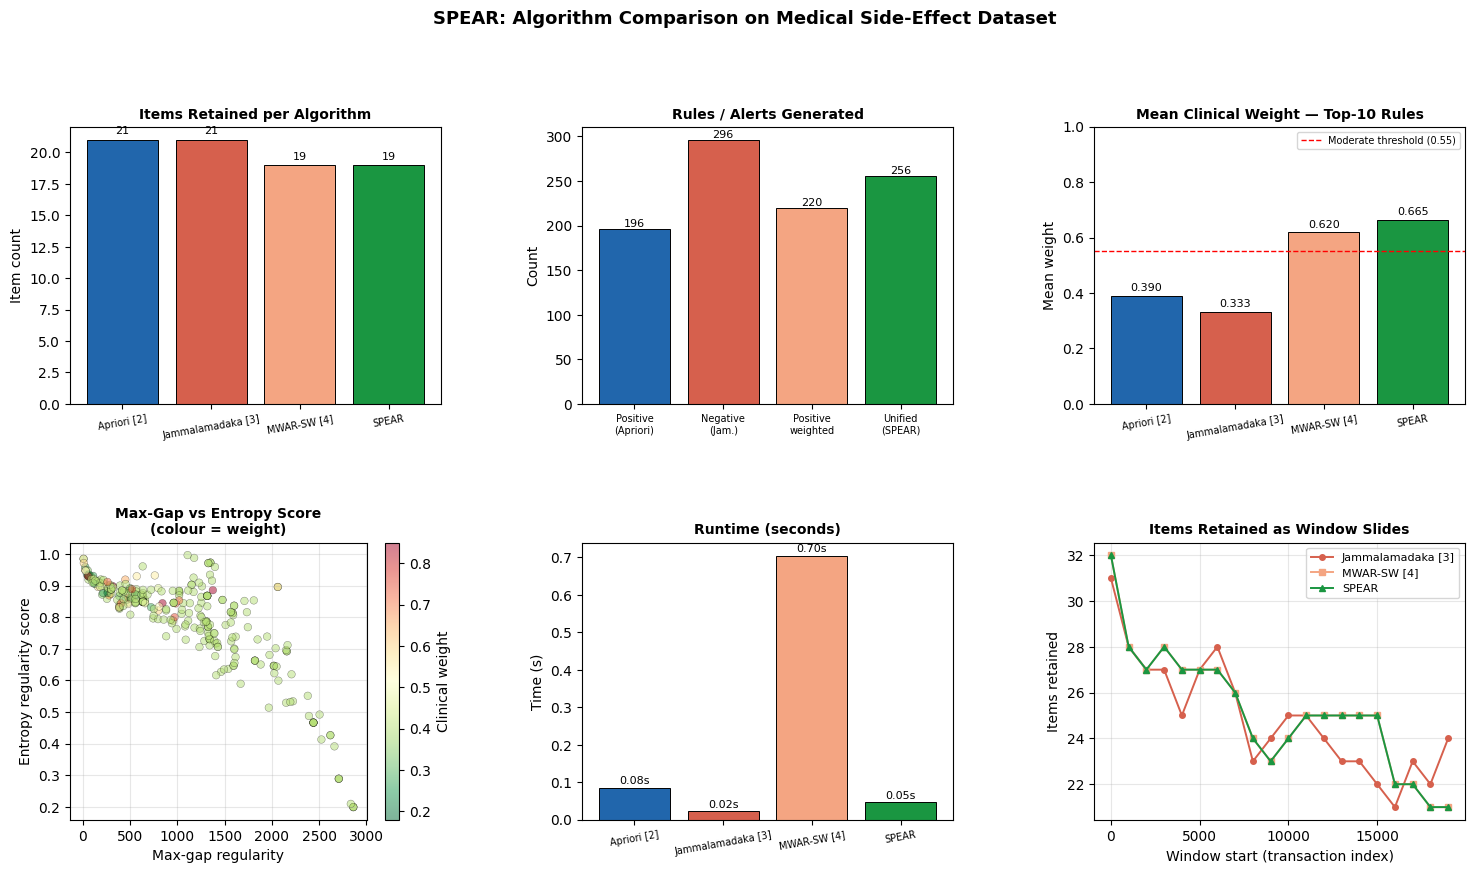

Figure saved: spear_comparison.png


In [15]:
COLORS = {
    'apriori': '#2166ac',
    'jam':     '#d6604d',
    'mwar':    '#f4a582',
    'spear':   '#1a9641'
}
ALGO_LABELS = ['Apriori [2]', 'Jammalamadaka [3]', 'MWAR-SW [4]', 'SPEAR']
ALGO_COLORS = [COLORS['apriori'], COLORS['jam'], COLORS['mwar'], COLORS['spear']]

fig = plt.figure(figsize=(18, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)


# --- Plot 1: Items retained -----------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
retained_counts = [
    n_freq_flat, len(jam_retained), len(mwar_retained), len(spear_retained)
]
bars = ax1.bar(ALGO_LABELS, retained_counts, color=ALGO_COLORS, edgecolor='black', linewidth=0.7)
ax1.set_title('Items Retained per Algorithm', fontsize=10, fontweight='bold')
ax1.set_ylabel('Item count')
ax1.tick_params(axis='x', labelsize=7, rotation=10)
for bar, v in zip(bars, retained_counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(v), ha='center', va='bottom', fontsize=8)


# --- Plot 2: Rules / alerts generated --------------------------------
ax2 = fig.add_subplot(gs[0, 1])
rules_counts = [
    len(apriori_rules), len(jam_rules), len(mwar_rules), len(spear_rules)
]
rule_labels = ['Positive\n(Apriori)', 'Negative\n(Jam.)', 'Positive\nweighted', 'Unified\n(SPEAR)']
bars2 = ax2.bar(rule_labels, rules_counts, color=ALGO_COLORS, edgecolor='black', linewidth=0.7)
ax2.set_title('Rules / Alerts Generated', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', labelsize=7)
for bar, v in zip(bars2, rules_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(v), ha='center', va='bottom', fontsize=8)


# --- Plot 3: Average weight of top-10 rules --------------------------
ax3 = fig.add_subplot(gs[0, 2])
avg_weights = [avg_w_apriori, avg_w_jam, avg_w_mwar, avg_w_spear]
bars3 = ax3.bar(ALGO_LABELS, avg_weights, color=ALGO_COLORS, edgecolor='black', linewidth=0.7)
ax3.set_title('Mean Clinical Weight — Top-10 Rules', fontsize=10, fontweight='bold')
ax3.set_ylabel('Mean weight')
ax3.set_ylim(0, 1.0)
ax3.axhline(0.55, color='red', linestyle='--', linewidth=1, label='Moderate threshold (0.55)')
ax3.tick_params(axis='x', labelsize=7, rotation=10)
ax3.legend(fontsize=7)
for bar, v in zip(bars3, avg_weights):
    ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=8)


# --- Plot 4: Entropy regularity score vs max-gap --------------------
ax4 = fig.add_subplot(gs[1, 0])
if spear_stats:
    items_for_plot = [(s['reg'], s['reg_score'], s['weight']) for s in spear_stats.values()
                      if s['reg_score'] > 0 and s['reg'] < 3000]
    if items_for_plot:
        regs, scores, weights = zip(*items_for_plot)
        sc = ax4.scatter(regs, scores, c=weights, cmap='RdYlGn_r', alpha=0.5,
                         edgecolors='black', linewidths=0.3, s=30)
        plt.colorbar(sc, ax=ax4, label='Clinical weight')
        ax4.set_xlabel('Max-gap regularity')
        ax4.set_ylabel('Entropy regularity score')
        ax4.set_title('Max-Gap vs Entropy Score\n(colour = weight)', fontsize=10, fontweight='bold')
        ax4.grid(alpha=0.3)
else:
    ax4.set_title('Entropy vs Max-Gap', fontsize=10, fontweight='bold')


# --- Plot 5: Runtime -------------------------------------------------
ax5 = fig.add_subplot(gs[1, 1])
runtimes = [apriori_time, jam_time, mwar_time, spear_time]
bars5 = ax5.bar(ALGO_LABELS, runtimes, color=ALGO_COLORS, edgecolor='black', linewidth=0.7)
ax5.set_title('Runtime (seconds)', fontsize=10, fontweight='bold')
ax5.set_ylabel('Time (s)')
ax5.tick_params(axis='x', labelsize=7, rotation=10)
for bar, v in zip(bars5, runtimes):
    ax5.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
             f'{v:.2f}s', ha='center', va='bottom', fontsize=8)


# --- Plot 6: Sliding window — items retained -------------------------
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(sw_df['window_start'], sw_df['jam'],   label='Jammalamadaka [3]',
         color=COLORS['jam'],   marker='o', markersize=4, linewidth=1.4)
ax6.plot(sw_df['window_start'], sw_df['mwar'],  label='MWAR-SW [4]',
         color=COLORS['mwar'],  marker='s', markersize=4, linewidth=1.4)
ax6.plot(sw_df['window_start'], sw_df['spear'], label='SPEAR',
         color=COLORS['spear'], marker='^', markersize=4, linewidth=1.4)
ax6.set_xlabel('Window start (transaction index)')
ax6.set_ylabel('Items retained')
ax6.set_title('Items Retained as Window Slides', fontsize=10, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)


fig.suptitle(
    'SPEAR: Algorithm Comparison on Medical Side-Effect Dataset',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('spear_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: spear_comparison.png")

## Section 16 : Entropy Regularity vs Max-Gap Regularity

**The problem with max-gap**

Jammalamadaka uses a single flat rule: the longest gap between two consecutive appearances of a side effect must not exceed 600 transactions. This is fragile. A side effect that appears consistently at regular intervals throughout the window but is missing just once near the end can have a single large gap that causes the whole item to be discarded.

Example: a side effect appears at positions 10, 20, 30, ..., 590, then once more at position 2990. Max-gap = 2400 and it is discarded by Jammalamadaka. SPEAR's entropy score for this item would be close to 1 (nearly uniform spacing), so it is correctly retained.

**SPEAR's adaptive threshold**

SPEAR's regularity threshold is not flat - it scales with the item's clinical weight. A life-threatening side effect must have near-perfect regularity to be trusted. A trivial one is accepted even if its spacing is somewhat uneven.

| Clinical weight | Minimum regularity score required |
|-----------------|-----------------------------------|
| 0.10 (trivial) | 0.10 - irregular spacing accepted |
| 0.50 (moderate) | 0.50 - reasonably even spacing required |
| 0.80 (severe) | 0.80 - highly consistent spacing required |
| 1.00 (critical) | 1.00 - perfectly uniform spacing required |

In [16]:
# Show how entropy regularity threshold works with weight
print("SPEAR Entropy Regularity: item passes if reg_score(X) >= omega(X)")
print("  reg_score = normalised Shannon entropy of gap distribution [0, 1]")
print("  1 = perfectly evenly spaced, 0 = maximally irregular")
print()
print(f"{'Clinical weight':>18} {'min reg_score':>14} {'Interpretation':<45}")
print("-" * 80)
for w in [0.10, 0.30, 0.50, 0.72, 0.80, 0.95]:
    if w >= 0.90:
        interp = "Critical — gaps must be nearly uniform"
    elif w >= 0.70:
        interp = "Severe   — gaps must be highly consistent"
    elif w >= 0.50:
        interp = "Moderate — gaps should be fairly even"
    else:
        interp = "Mild     — tolerates uneven gap patterns"
    print(f"{w:>18.2f} {w:>14.2f}   {interp}")

print()
print("Jammalamadaka uses flat max-gap =", MAX_REG, "for all items regardless of weight.")
print("Max-gap is brittle: one outlier gap kills an otherwise regular item.")
print()
print("SPEAR uses entropy which considers the ENTIRE gap distribution,")
print("making it robust to occasional outlier gaps.")

SPEAR Entropy Regularity: item passes if reg_score(X) >= omega(X)
  reg_score = normalised Shannon entropy of gap distribution [0, 1]
  1 = perfectly evenly spaced, 0 = maximally irregular

   Clinical weight  min reg_score Interpretation                               
--------------------------------------------------------------------------------
              0.10           0.10   Mild     — tolerates uneven gap patterns
              0.30           0.30   Mild     — tolerates uneven gap patterns
              0.50           0.50   Moderate — gaps should be fairly even
              0.72           0.72   Severe   — gaps must be highly consistent
              0.80           0.80   Severe   — gaps must be highly consistent
              0.95           0.95   Critical — gaps must be nearly uniform

Jammalamadaka uses flat max-gap = 600 for all items regardless of weight.
Max-gap is brittle: one outlier gap kills an otherwise regular item.

SPEAR uses entropy which considers the ENTIRE

## Section 17 : Graceful Degradation Verification

A good algorithm should reduce to simpler known methods when its extra features are turned off. We verify this with two tests.

**Test 1 - Set all weights to 1.0 (maximum strictness)**

When every side effect has a weight of 1.0, SPEAR's regularity threshold becomes 1.0 for every item, meaning only perfectly uniformly-spaced items survive. This is stricter than Jammalamadaka's max-gap filter, confirming that SPEAR is a genuine generalisation rather than a weaker version.

**Test 2 - Disable the regularity filter**

When we bypass the entropy regularity check entirely and keep only the weighted support filter, SPEAR becomes a weighted positive-and-negative miner with no regularity constraint. As expected, more rules are generated than with full SPEAR, showing that the entropy regularity filter is genuinely pruning noisy, irregular items.

Together these two tests confirm that SPEAR contains and extends both Jammalamadaka and MWAR-SW as special cases.

In [17]:
# ---- Case (i): uniform weights (omega = 1) --------------------------
uniform_weights = {item: 1.0 for item in weight_dict}

stats_uniform = compute_item_statistics(window, uniform_weights)
# With omega=1 the entropy threshold is 1.0 (maximum strictness)
# Only perfectly regular items survive
retained_uniform = {
    item for item, s in stats_uniform.items()
    if s['wsup'] >= MIN_SUP  # wsup = 1*sup = sup when omega=1
    and s['reg_score'] >= 1.0
}
retained_jam_set = set(jam_retained.keys())

print("Graceful Degradation — Case (i): omega = 1 for all items")
print("-" * 60)
print(f"  Items retained by Jammalamadaka [3]          : {len(retained_jam_set)}")
print(f"  Items retained by SPEAR (omega=1, strict)    : {len(retained_uniform)}")
print(f"  (omega=1 enforces max strictness: only perfectly regular items pass)")

# ---- Case (ii): regularity disabled ---------------------------------
# Run SPEAR but override to accept all reg_scores (effectively no regularity filter)

def run_spear_no_reg(window, weight_dict, min_wsup, min_wneg_sup, min_wneg_conf, min_pos_conf):
    """SPEAR with entropy regularity disabled."""
    t0 = time.time()
    n  = len(window)
    stats = compute_item_statistics(window, weight_dict)
    retained = {item: {**s, 'reg_score': s.get('reg_score', 0)}
                for item, s in stats.items() if s['wsup'] >= min_wsup}
    items = sorted(retained.keys())
    rules = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            A, B = items[i], items[j]
            sup_AB = joint_support(retained[A]['tid_list'], retained[B]['tid_list'], n)
            sup_A, sup_B = retained[A]['sup'], retained[B]['sup']
            w_A, w_B = retained[A]['weight'], retained[B]['weight']
            wsup_A = retained[A]['wsup']
            avg_w = (w_A + w_B) / 2.0
            for ant, cons, sup_ant, w_ant, w_cons, wsup_ant in [
                (A, B, sup_A, w_A, w_B, wsup_A),
                (B, A, sup_B, w_B, w_A, retained[B]['wsup'])
            ]:
                w_neg_sup = w_ant * w_cons * (sup_ant - sup_AB)
                if w_neg_sup > 0 and wsup_ant > 0:
                    w_neg_conf = w_neg_sup / wsup_ant
                    if w_neg_sup >= min_wneg_sup and w_neg_conf >= min_wneg_conf:
                        rules.append({'rule_type': 'NEGATIVE', 'severity': w_neg_conf * avg_w})
            if sup_AB > 0:
                for ant, cons, sup_ant, w_ant, w_cons in [
                    (A, B, sup_A, w_A, w_B), (B, A, sup_B, w_B, w_A)
                ]:
                    if sup_ant > 0:
                        conf = sup_AB / sup_ant
                        if conf >= min_pos_conf:
                            rules.append({'rule_type': 'POSITIVE', 'severity': conf * w_cons * avg_w})
    return pd.DataFrame(rules) if rules else pd.DataFrame(), retained, time.time() - t0

rules_noreg, retained_noreg, t_noreg = run_spear_no_reg(
    window, weight_dict, MIN_WSUP, MIN_WNEG_SUP, MIN_WNEG_CONF, MIN_CONF
)

print()
print("Graceful Degradation — Case (ii): regularity disabled")
print("-" * 60)
print(f"  Items retained (wsup only, no entropy)   : {len(retained_noreg)}")
n_neg_noreg = len(rules_noreg[rules_noreg['rule_type'] == 'NEGATIVE']) if len(rules_noreg) > 0 else 0
n_pos_noreg = len(rules_noreg[rules_noreg['rule_type'] == 'POSITIVE']) if len(rules_noreg) > 0 else 0
print(f"  Negative rules                           : {n_neg_noreg}")
print(f"  Positive rules                           : {n_pos_noreg}")
print(f"  Total rules                              : {len(rules_noreg)}")
print(f"  (This is a weighted pos+neg miner without regularity)")

Graceful Degradation — Case (i): omega = 1 for all items
------------------------------------------------------------
  Items retained by Jammalamadaka [3]          : 21
  Items retained by SPEAR (omega=1, strict)    : 0
  (omega=1 enforces max strictness: only perfectly regular items pass)

Graceful Degradation — Case (ii): regularity disabled
------------------------------------------------------------
  Items retained (wsup only, no entropy)   : 19
  Negative rules                           : 196
  Positive rules                           : 60
  Total rules                              : 256
  (This is a weighted pos+neg miner without regularity)


## Section 18 : Precision@K - Clinical Relevance in Top-K Rules

**What it measures**

Precision@K answers: "Of the top K rules returned by the algorithm, what fraction involves at least one clinically severe side effect (weight >= 0.65)?" A score of 1.0 means every top-K rule is clinically significant.

This metric matters because in a real pharmacovigilance setting, an analyst cannot review hundreds of rules. They need the most dangerous signals to appear at the top. An algorithm that buries critical alerts under low-severity noise is not useful in practice.

**Why we compare Jammalamadaka and SPEAR here**

Both algorithms produce negative rules (incompatibility alerts). Jammalamadaka ranks them purely by how strongly the two side effects avoid each other, with no regard for how dangerous they are. SPEAR ranks them by a score that combines both the strength of the avoidance and the clinical severity of both side effects. We expect SPEAR to have a higher Precision@K at every value of K, meaning its top rules are consistently more clinically relevant.

Precision@K — Fraction of top-K rules with clinical weight ≥ 0.65
     K    Jammalamadaka [3]        SPEAR
----------------------------------------------------
     5                0.000        1.000
    10                0.000        1.000
    15                0.133        1.000
    20                0.200        1.000
    30                0.267        1.000
    50                0.220        0.900


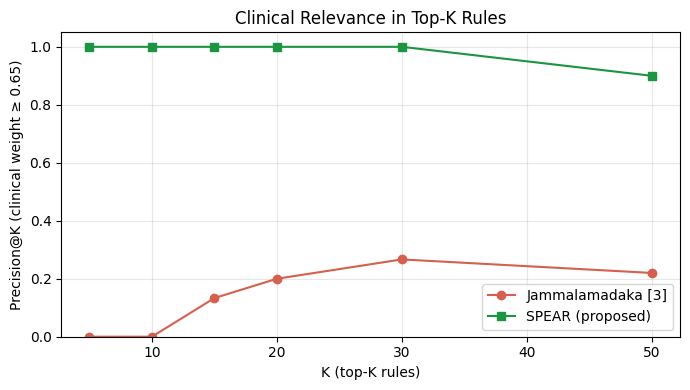


Average Precision@K improvement (SPEAR over Jammalamadaka): +0.847


In [18]:
# ── Precision@K: clinical relevance in top-K rules ───────────────────

def precision_at_k(df, k, weight_cols, threshold=0.65):
    """Fraction of top-k rules where max weight >= threshold."""
    top = df.head(min(k, len(df)))
    if len(top) == 0:
        return 0.0
    return (top[weight_cols].max(axis=1) >= threshold).mean()

K_values = [5, 10, 15, 20, 30, 50]

prec_jam   = [precision_at_k(jam_rules,   k, ['weight_ant', 'weight_cons']) for k in K_values]
prec_spear = [precision_at_k(spear_rules, k, ['weight_ant', 'weight_cons']) for k in K_values]

# ── Tabular summary ──────────────────────────────────────────────────
print("Precision@K — Fraction of top-K rules with clinical weight ≥ 0.65")
print("=" * 52)
print(f"  {'K':>4}   {'Jammalamadaka [3]':>18}   {'SPEAR':>10}")
print("-" * 52)
for k, pj, ps in zip(K_values, prec_jam, prec_spear):
    print(f"  {k:>4}   {pj:>18.3f}   {ps:>10.3f}")
print("=" * 52)

# ── Plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(K_values, prec_jam,   'o-', color='#d6604d', label='Jammalamadaka [3]', linewidth=1.5)
plt.plot(K_values, prec_spear, 's-', color='#1a9641', label='SPEAR (proposed)',  linewidth=1.5)
plt.xlabel('K (top-K rules)')
plt.ylabel('Precision@K (clinical weight ≥ 0.65)')
plt.title('Clinical Relevance in Top-K Rules')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Improvement summary ──────────────────────────────────────────────
avg_improvement = np.mean([ps - pj for ps, pj in zip(prec_spear, prec_jam)])
print(f"\nAverage Precision@K improvement (SPEAR over Jammalamadaka): +{avg_improvement:.3f}")

## Section 19 : Export All Rules to CSV

We save the complete rule sets of all four algorithms to the `exported_rules/` folder for external inspection, further analysis, or use in tools such as Weka.

| File | Content |
|------|---------|
| `apriori_positive_rules.csv` | Positive rules from Algorithm 1, ranked by confidence |
| `jammalamadaka_negative_rules.csv` | Negative rules from Algorithm 2, ranked by negative confidence |
| `mwar_sw_positive_rules.csv` | Positive weighted rules from Algorithm 3, ranked by weighted confidence |
| `spear_rules.csv` | Unified positive and negative rules from Algorithm 4, ranked by severity score |

In [19]:
import os

OUTPUT_DIR = 'exported_rules'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Algorithm 1: Standard Apriori (positive rules) -----------------
if len(apriori_rules) > 0:
    ap_export = apriori_rules.copy()
    ap_export['antecedents'] = ap_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    ap_export['consequents'] = ap_export['consequents'].apply(lambda x: ', '.join(sorted(x)))
    ap_export.to_csv(os.path.join(OUTPUT_DIR, 'apriori_positive_rules.csv'), index=False)
    print(f"[1] Apriori:       {len(ap_export)} positive rules  -> {OUTPUT_DIR}/apriori_positive_rules.csv")
else:
    print("[1] Apriori:       no rules to export.")

# ---- Algorithm 2: Jammalamadaka & Budaraju (negative rules) ----------
if len(jam_rules) > 0:
    jam_rules.to_csv(os.path.join(OUTPUT_DIR, 'jammalamadaka_negative_rules.csv'), index=False)
    print(f"[2] Jammalamadaka: {len(jam_rules)} negative rules -> {OUTPUT_DIR}/jammalamadaka_negative_rules.csv")
else:
    print("[2] Jammalamadaka: no rules to export.")

# ---- Algorithm 3: MWAR-SW / Ouyang & Huang (positive weighted) ------
if len(mwar_rules) > 0:
    mw_export = mwar_rules.copy()
    mw_export['antecedents'] = mw_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    mw_export['consequents'] = mw_export['consequents'].apply(lambda x: ', '.join(sorted(x)))
    mw_export.to_csv(os.path.join(OUTPUT_DIR, 'mwar_sw_positive_rules.csv'), index=False)
    print(f"[3] MWAR-SW:       {len(mw_export)} positive rules  -> {OUTPUT_DIR}/mwar_sw_positive_rules.csv")
else:
    print("[3] MWAR-SW:       no rules to export.")

# ---- Algorithm 4: SPEAR (unified positive + negative rules) ---------
if len(spear_rules) > 0:
    spear_rules.to_csv(os.path.join(OUTPUT_DIR, 'spear_rules.csv'), index=False)
    print(f"[4] SPEAR:         {len(spear_rules)} unified rules   -> {OUTPUT_DIR}/spear_rules.csv")
else:
    print("[4] SPEAR:         no rules to export.")

print(f"\nAll files saved to: {os.path.abspath(OUTPUT_DIR)}/")

[1] Apriori:       196 positive rules  -> exported_rules/apriori_positive_rules.csv
[2] Jammalamadaka: 296 negative rules -> exported_rules/jammalamadaka_negative_rules.csv
[3] MWAR-SW:       220 positive rules  -> exported_rules/mwar_sw_positive_rules.csv
[4] SPEAR:         256 unified rules   -> exported_rules/spear_rules.csv

All files saved to: c:\Users\victus\Desktop\M1 IV S2\Data_mining\Contribution_approved\exported_rules/
